In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("SampleSuperstore.csv", encoding='latin1')

In [7]:
print(df.head())
print(df.info())
print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [11]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

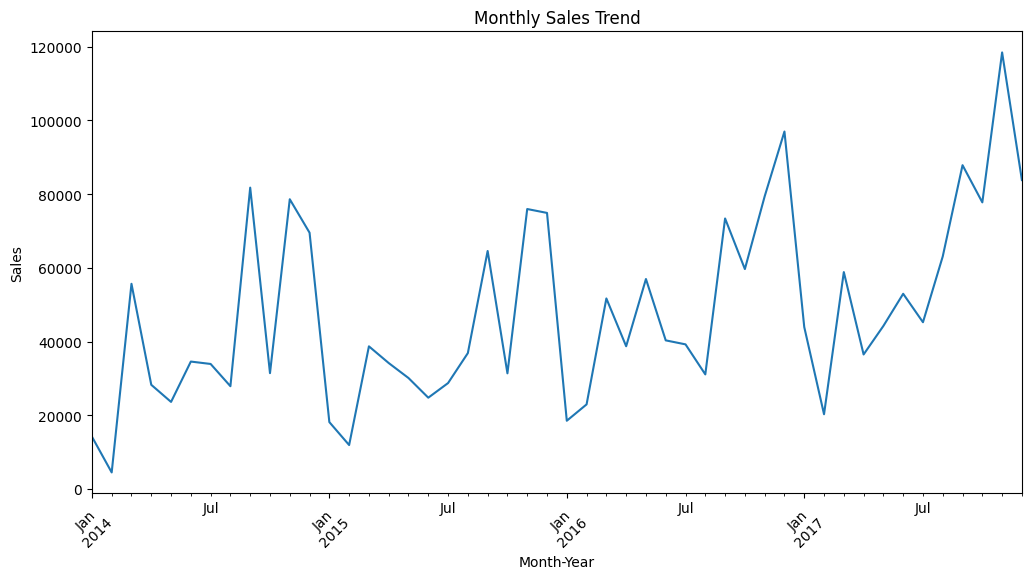

In [12]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.show()

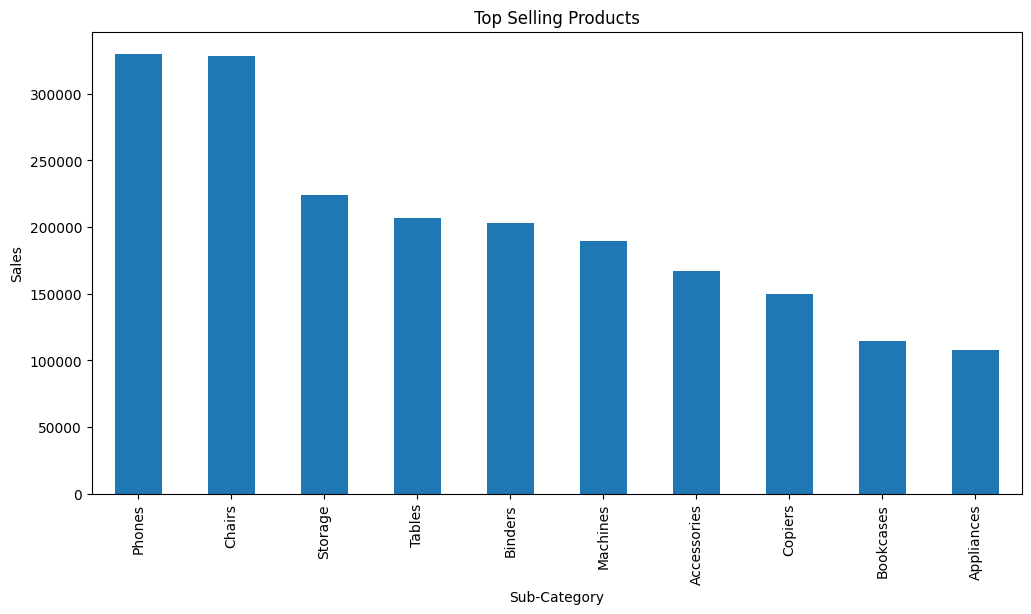

In [13]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_products.head(10).plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.show()

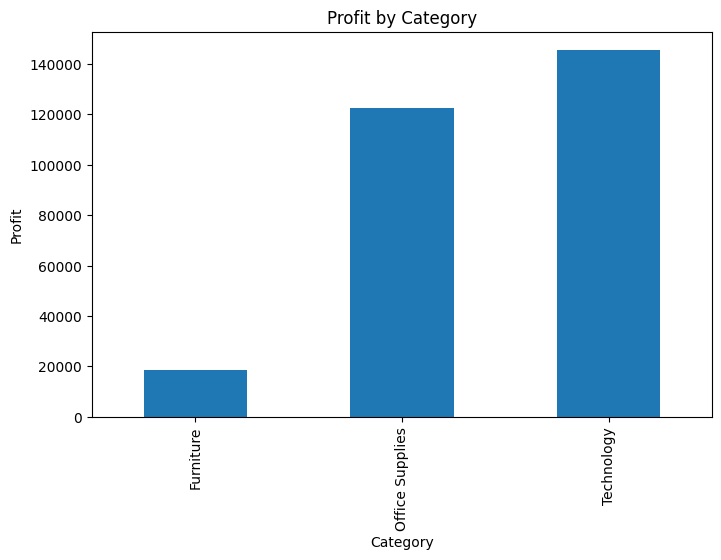

In [14]:
profit_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

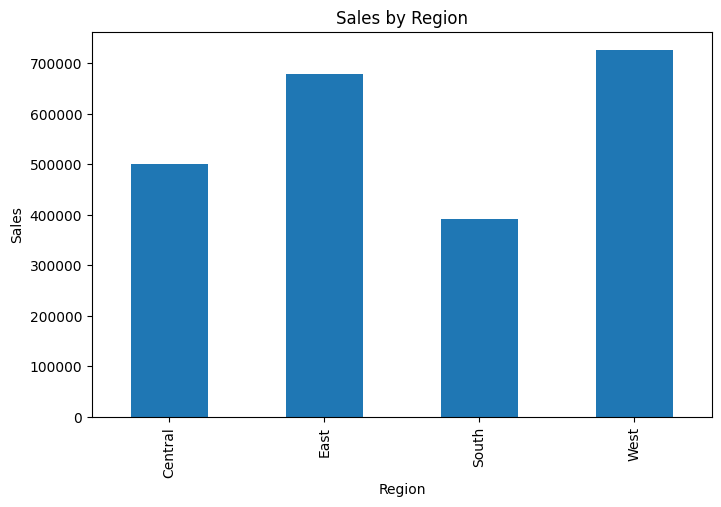

In [15]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

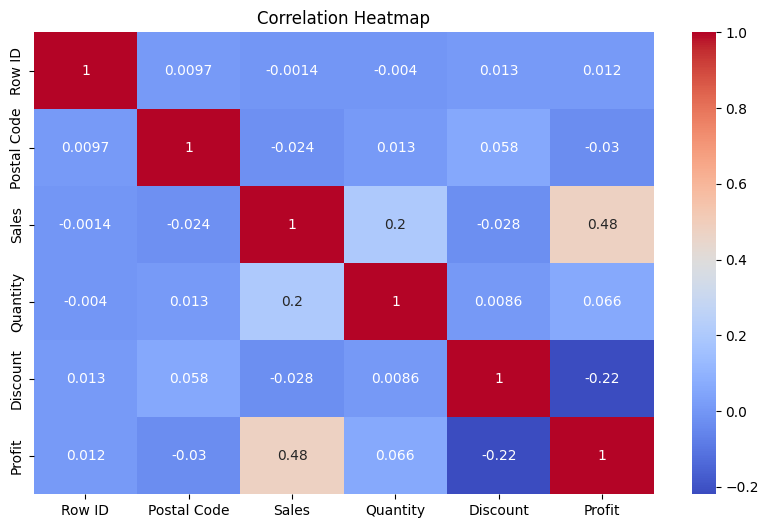

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#1. Technology category generated highest sales.
#2. Western region contributed maximum revenue.
#3. Some categories had high sales but low profit.
# 4. Sales increased during specific months indicating seasonal trends.

# The analysis identified sales trends, profitable categories, and regional performance patterns. These insights can help businesses optimize inventory and marketing strategies.

In [18]:
df.to_csv("cleaned_superstore.csv", index=False)